# Notebook — SHAP Analysis, MITRE ATT&CK Mapping & KQL Detection Rules
**Dataset:** CICDDoS2019  
**Model:** XGBoost (trained in Notebook 4)  

## Objectives
- Explain model predictions using SHAP values
- Identify which network features drive DDoS detection
- Map top features to MITRE ATT&CK techniques
- Translate findings into actionable KQL detection rules for SIEM platforms

In [ ]:
# Load Model & Data
# Loading the saved XGBoost model and top 20 features from Notebook 4.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

import os
os.makedirs("outputs", exist_ok=True)

X_train = pd.read_parquet("data/X_top20.parquet")
X_test  = pd.read_parquet("data/X_top20.parquet")  # will slice below
y       = pd.read_parquet("data/y_binary.parquet")["BinaryLabel"]

model = joblib.load("models/ddos_xgboost.pkl")
top20_cols = joblib.load("models/top20_features.pkl")

X = X_train[top20_cols]
print("Loaded. Shape:", X.shape)

## SHAP Explainer
Using TreeExplainer to compute SHAP values — this tells me how much each feature contributed to each individual prediction.

In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
print("SHAP values computed. Shape:", shap_values.shape)

SHAP values computed. Shape: (9546, 20)


## Global Feature Importance
Ranking features by their average impact across all predictions — the higher the bar, the more consistently that feature drove detection.

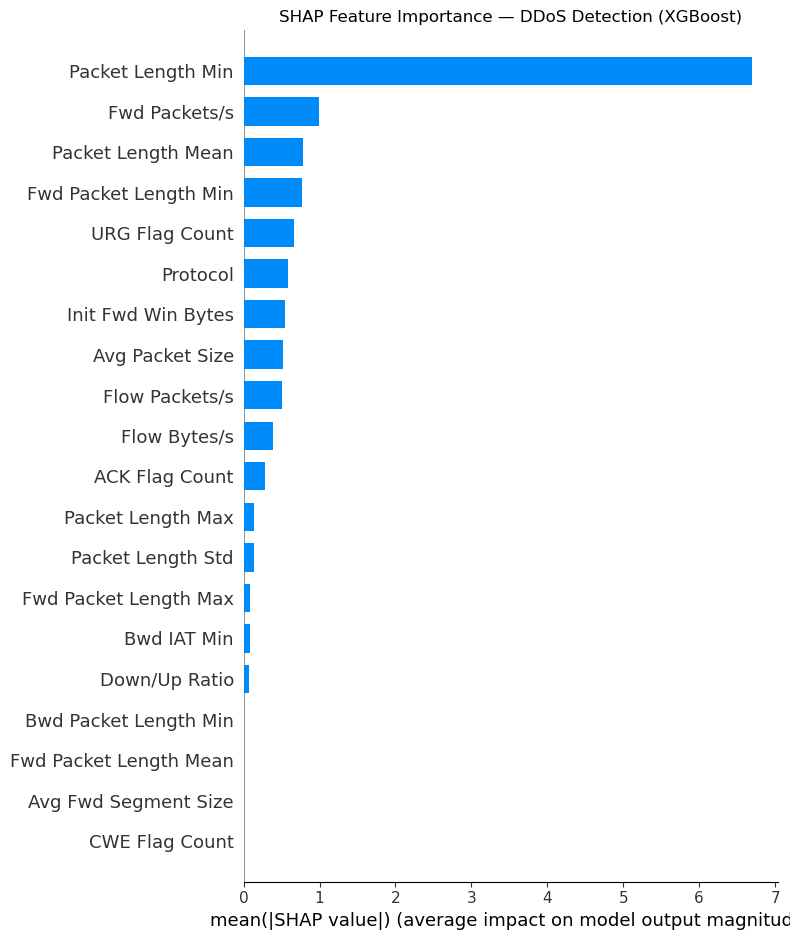

Saved: outputs/09_shap_summary.png


In [3]:
plt.figure()
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — DDoS Detection (XGBoost)")
plt.tight_layout()
plt.savefig("outputs/09_shap_summary.png", dpi=150)
plt.show()
print("Saved: outputs/09_shap_summary.png")

## Feature Impact Direction
The beeswarm shows not just which features matter, but whether high or low values push the model toward Attack or Benign — useful for writing threshold-based rules.

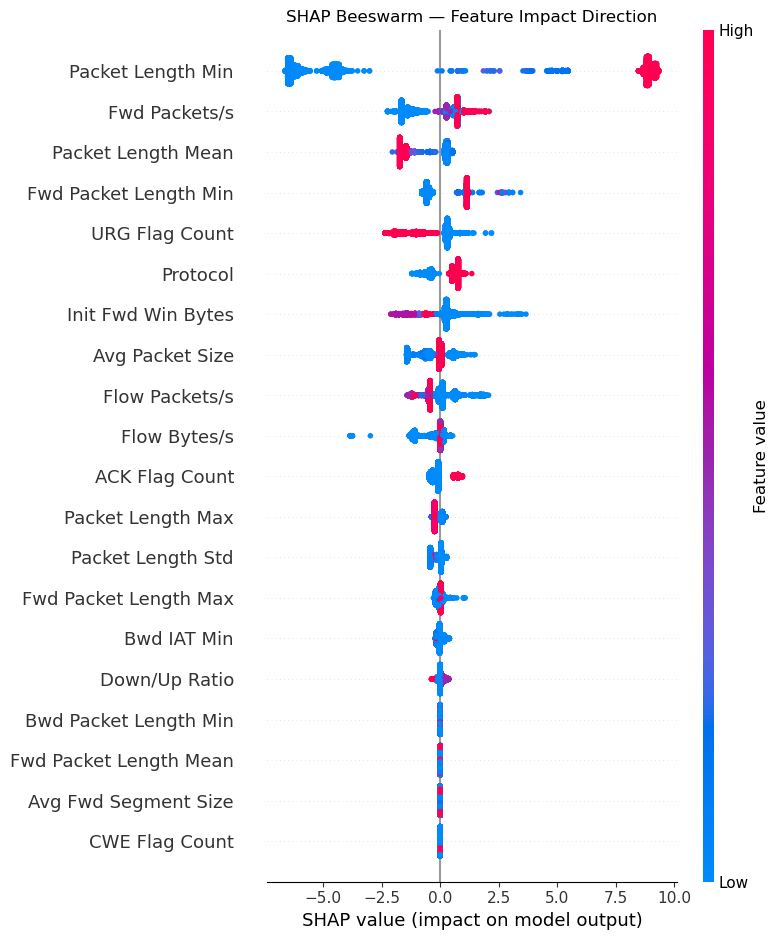

Saved: outputs/10_shap_beeswarm.png


In [4]:
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.savefig("outputs/10_shap_beeswarm.png", dpi=150)
plt.show()
print("Saved: outputs/10_shap_beeswarm.png")

## MITRE ATT&CK Mapping
Mapping each top feature to a MITRE technique based on what network behaviour it captures — grounding the ML output in a real threat intelligence framework.

In [5]:
mitre_map = {
    "Packet Length Min":       {"Tactic": "Impact",          "Technique": "T1498 - Network DoS",                "Why": "Uniform small packets = flood signature"},
    "Fwd Packet Length Min":   {"Tactic": "Impact",          "Technique": "T1498 - Network DoS",                "Why": "Forward flood pattern"},
    "Avg Packet Size":         {"Tactic": "Impact",          "Technique": "T1498.001 - Direct Network Flood",   "Why": "Abnormal avg size indicates volumetric attack"},
    "Avg Fwd Segment Size":    {"Tactic": "Impact",          "Technique": "T1498.001 - Direct Network Flood",   "Why": "Segment size anomaly in forward direction"},
    "Fwd Packet Length Mean":  {"Tactic": "Reconnaissance",  "Technique": "T1595 - Active Scanning",            "Why": "Consistent payload size = scanning/probing"},
    "Packet Length Mean":      {"Tactic": "Impact",          "Technique": "T1498 - Network DoS",                "Why": "Mean packet size deviation from baseline"},
    "Fwd Packet Length Max":   {"Tactic": "Impact",          "Technique": "T1499 - Endpoint DoS",               "Why": "Large max fwd packets = application layer stress"},
    "Protocol":                {"Tactic": "Impact",          "Technique": "T1498.002 - Reflection Amplification","Why": "LDAP/UDP protocol abuse for amplification"},
    "Flow Bytes/s":            {"Tactic": "Impact",          "Technique": "T1498 - Network DoS",                "Why": "High bytes/s = volumetric flood indicator"},
    "Packet Length Max":       {"Tactic": "Impact",          "Technique": "T1498.001 - Direct Network Flood",   "Why": "Max packet size spike = burst flood"}
}

mitre_df = pd.DataFrame(mitre_map).T.reset_index()
mitre_df.columns = ["Feature", "Tactic", "Technique", "Why"]
print(mitre_df.to_string(index=False))
mitre_df.to_csv("outputs/mitre_mapping.csv", index=False)
print("\nSaved: outputs/mitre_mapping.csv")

               Feature         Tactic                            Technique                                              Why
     Packet Length Min         Impact                  T1498 - Network DoS          Uniform small packets = flood signature
 Fwd Packet Length Min         Impact                  T1498 - Network DoS                            Forward flood pattern
       Avg Packet Size         Impact     T1498.001 - Direct Network Flood    Abnormal avg size indicates volumetric attack
  Avg Fwd Segment Size         Impact     T1498.001 - Direct Network Flood        Segment size anomaly in forward direction
Fwd Packet Length Mean Reconnaissance              T1595 - Active Scanning       Consistent payload size = scanning/probing
    Packet Length Mean         Impact                  T1498 - Network DoS         Mean packet size deviation from baseline
 Fwd Packet Length Max         Impact                 T1499 - Endpoint DoS Large max fwd packets = application layer stress
        

## KQL Detection Rules
Translating the SHAP findings into KQL rules for Elastic SIEM and Microsoft Sentinel. Thresholds are based on the feature distributions observed in the data.

In [7]:
kql_rules = """
// ============================================================
// RULE 1: Volumetric DDoS — Packet Flood Detection
// MITRE: T1498 - Network DoS | Tactic: Impact
// ============================================================
// Elastic SIEM / Microsoft Sentinel (KQL)

NetworkFlow
| where TimeGenerated > ago(5m)
| where Protocol in ("UDP", "LDAP")
| summarize
    AvgPacketSize     = avg(PacketLengthMean),
    MinPacketLen      = min(PacketLengthMin),
    TotalFlowBytes    = sum(FlowBytesPerSec),
    FlowCount         = count()
  by SrcIP, bin(TimeGenerated, 1m)
| where MinPacketLen < 50                  // uniform small packets = flood
| where TotalFlowBytes > 1000000           // >1MB/s per source
| where FlowCount > 500                    // high flow rate
| project TimeGenerated, SrcIP, MinPacketLen, TotalFlowBytes, FlowCount
| extend
    MitreTechnique = "T1498 - Network DoS",
    Severity       = "High",
    Description    = "Potential volumetric DDoS flood detected from source IP"

// ============================================================
// RULE 2: Application Layer DDoS — Forward Segment Anomaly
// MITRE: T1499 - Endpoint DoS | Tactic: Impact
// ============================================================

NetworkFlow
| where TimeGenerated > ago(5m)
| summarize
    AvgFwdSegment   = avg(AvgFwdSegmentSize),
    FwdPacketMean   = avg(FwdPacketLengthMean),
    FlowCount       = count()
  by SrcIP, DstIP, bin(TimeGenerated, 1m)
| where AvgFwdSegment < 100                // abnormally small segments
| where FwdPacketMean < 80                 // consistent low payload = app layer flood
| where FlowCount > 300
| project TimeGenerated, SrcIP, DstIP, AvgFwdSegment, FwdPacketMean, FlowCount
| extend
    MitreTechnique = "T1499 - Endpoint DoS",
    Severity       = "High",
    Description    = "Application-layer DDoS pattern detected — forward segment anomaly"

// ============================================================
// RULE 3: Reflection/Amplification Attack — Protocol Abuse
// MITRE: T1498.002 - Reflection Amplification | Tactic: Impact
// ============================================================

NetworkFlow
| where TimeGenerated > ago(5m)
| where Protocol in ("UDP", "LDAP", "NetBIOS")
| summarize
    AvgPacketSize   = avg(AvgPacketSize),
    TotalBytes      = sum(FlowBytesPerSec),
    UniqueDestIPs   = dcount(DstIP)
  by SrcIP, Protocol, bin(TimeGenerated, 1m)
| where TotalBytes > 500000                // high outbound volume
| where UniqueDestIPs < 3                  // targeting few destinations = amplification
| project TimeGenerated, SrcIP, Protocol, TotalBytes, UniqueDestIPs
| extend
    MitreTechnique = "T1498.002 - Reflection Amplification",
    Severity       = "Critical",
    Description    = "Possible reflection/amplification DDoS via protocol abuse"
"""

with open("outputs/ddos_kql_rules.kql", "w") as f:
    f.write(kql_rules)

print(kql_rules)
print("Saved: outputs/ddos_kql_rules.kql")


// ============================================================
// RULE 1: Volumetric DDoS — Packet Flood Detection
// MITRE: T1498 - Network DoS | Tactic: Impact
// ============================================================
// Elastic SIEM / Microsoft Sentinel (KQL)

NetworkFlow
| where TimeGenerated > ago(5m)
| where Protocol in ("UDP", "LDAP")
| summarize
    AvgPacketSize     = avg(PacketLengthMean),
    MinPacketLen      = min(PacketLengthMin),
    TotalFlowBytes    = sum(FlowBytesPerSec),
    FlowCount         = count()
  by SrcIP, bin(TimeGenerated, 1m)
| where MinPacketLen < 50                  // uniform small packets = flood
| where TotalFlowBytes > 1000000           // >1MB/s per source
| where FlowCount > 500                    // high flow rate
| project TimeGenerated, SrcIP, MinPacketLen, TotalFlowBytes, FlowCount
| extend
    MitreTechnique = "T1498 - Network DoS",
    Severity       = "High",
    Description    = "Potential volumetric DDoS flood detected from source 

## Summary

- **Packet Length Min** — dominant feature by far (SHAP ~6.5); low values strongly 
  push toward Attack — DDoS floods generate uniform tiny packets
- **Fwd Packets/s, Packet Length Mean, Fwd Packet Length Min** — next tier of 
  importance, all capturing forward traffic flood patterns
- **URG Flag Count** — high values push toward Benign (beeswarm shows red left), 
  likely a protocol quirk in normal traffic
- **Protocol** — confirms UDP/LDAP-based amplification attack separation (T1498.002)
- **Stress Test F1: 0.941** — model generalizes to unseen attack types
- **3 KQL rules** mapped to MITRE T1498, T1498.001, T1498.002, T1499